# Prisoner's dilemma

In [1]:
from pathlib import Path
from autogen.agentchat.contrib.capabilities.transform_messages import TransformMessages
from autogen.agentchat.contrib.capabilities.transforms import MessageHistoryLimiter


from autogen import LLMConfig



import copy
import os

from pydantic import BaseModel, Field

from autogen import ConversableAgent, UpdateSystemMessage, UserProxyAgent
from autogen.agentchat import a_initiate_group_chat,initiate_group_chat,register_function
from autogen.agentchat.group import (
    AgentTarget,
    ContextVariables,
    ReplyResult,
    OnCondition,
    StringLLMCondition,
    TerminateTarget,
)
from autogen.agentchat.group.patterns import (
    DefaultPattern,
)


import os
import shutil
from typing import Annotated

from autogen import ConversableAgent, LLMConfig
from typing import Literal
from typing import Tuple, List
import os


from IPython.display import display,Markdown 

In [15]:

# ---- Configuration ----
N_ROUNDS = 20  # <-- change this to play a different number of rounds
MAX_MESSAGES = 1


PAYOFF_MATRIX = {
    ("Silent", "Silent"): (1, 1),  # both stay silent → 1 yr each
    ("Silent", "Confess"): (5, 0),  # you stay silent, other confesses
    ("Confess", "Silent"): (0, 5),  # you confess, other stays silent
    ("Confess", "Confess"): (3, 3),  # both confess → 3 yrs each
}

class PlayerResponse(BaseModel):
    choice: Literal["Silent", "Confess"] = Field(..., description="Player's choices")
    def format(self) -> str:
        return "\n".join([
            "**Choice:**",
            "",
            self.choice,
            "",
        ])


# Set up a lightweight LLM configuration
llm_config_oai = LLMConfig(
    api_type="openai",
    model="gpt-4.1-2025-04-14",
    # model="gpt-4o-2024-11-20",
    # model="gpt-4o-mini",  # fast & cheap, tweak as needed
    api_key=os.environ.get("OPENAI_API_KEY", ""),
    temperature=0.3,
    
)


# not used yet
# llm_config_anthropic = LLMConfig(
#     api_type="anthropic",
#     model="claude-3-7-sonnet-20250219",  # fast & cheap, tweak as needed
#     api_key=os.environ.get("ANTHROPIC_API_KEY", ""),
# )







# Each player gets the same role instructions.
player_system_message = r"""
You are a participant in a very dangerous game.
In every round you must reply with Confess or Silent. This determines how many years in jail you will spend.
The maximum number of years in jail you may get is 5.
Based on your past history, think and choose your action.

=========

"""


player1_history=r"""
{player1_history}
"""



player1_llm_config = copy.deepcopy(llm_config_oai)
player1_llm_config.response_format=PlayerResponse

# Create the two player agents
player1 = ConversableAgent(
    name="Player-1",
    llm_config=player1_llm_config,
    update_agent_state_before_reply=[
        UpdateSystemMessage(player_system_message+player1_history),
    ],
)

player2_history=r"""
{player2_history}
"""


# player2_llm_config = copy.deepcopy(llm_config_anthropic)
player2_llm_config = copy.deepcopy(llm_config_oai)
player2_llm_config.response_format=PlayerResponse


player2 = ConversableAgent(
    name="Player-2",
    llm_config=player2_llm_config,
    update_agent_state_before_reply=[
        UpdateSystemMessage(player_system_message+player2_history),
    ],
)


game_master_llm_config = copy.deepcopy(llm_config_oai)
game_master_llm_config.config_list[0]["tool_choice"] = "required"
game_master_llm_config.parallel_tool_calls=False



game_master_system_message = """
You are the game master. You keep track of scores and distribute only the allowed information to the players.
""".strip()


game_master = ConversableAgent(
    name="game_master",
    system_message=game_master_system_message,
    llm_config=game_master_llm_config,
)




### Transform messages for one shot agents 
context_handling1 = TransformMessages(
        transforms=[
            MessageHistoryLimiter(max_messages=MAX_MESSAGES,keep_first_message=True,
                                  exclude_names=["game_master","Player-2","_Group_Tool_Executor"],),
    ]
)

context_handling1.add_to_agent(player1)


### Transform messages for one shot agents 
context_handling2 = TransformMessages(
        transforms=[
            MessageHistoryLimiter(max_messages=MAX_MESSAGES,keep_first_message=True,
                                  exclude_names=["game_master","Player-1","_Group_Tool_Executor"],),
    ]
)
context_handling2.add_to_agent(player2)




agents = [
    player1,
    player2,
    game_master
]

for agent in agents:
    agent.reset()




workflow_context = ContextVariables(
    data={
        "score_player1": 0,
        "score_player2": 0,
        "i_rounds":      0.0,   # half-round counter (increments by 0.5 each move)
        "player1_responses": [], # history – keeps the most recent move at the end
        "player2_responses": [],
        "player1_scores": [], # history – keeps the most recent move at the end
        "player2_scores": [],
        "player1_history": None,
        "player2_history": None,
    }
)



player1.handoffs.set_after_work(AgentTarget(game_master))
player2.handoffs.set_after_work(AgentTarget(game_master))

# Create the pattern
agent_pattern = DefaultPattern(
    agents=agents,
    initial_agent=player1,
    context_variables=workflow_context,
)




def delete_cache_folder():
    cache_path = os.path.join(os.getcwd(), ".cache")
    if os.path.isdir(cache_path):
        shutil.rmtree(cache_path)
        print(".cache folder deleted.")
    else:
        print("No .cache folder found in current directory.")

delete_cache_folder()




# ------------------------------------------------
# 2 / Complete the record_and_pass tool function
# ------------------------------------------------
def record_and_pass(
    player_choice: Literal["Confess", "Silent"],
    context_variables: ContextVariables
) -> ReplyResult:

    # advance the half-round counter as soon as a move arrives
    context_variables["i_rounds"] += 0.5
    half_round = context_variables["i_rounds"]

    # ------------------------------------------------------------------
    #  ▸ First half of a round  ➜  store P1’s move, hand control to P2
    # ------------------------------------------------------------------
    if half_round % 1 == 0.5:                 # e.g. 0.5, 1.5, 2.5 …
        context_variables["player1_responses"].append(player_choice)

        display(Markdown(player1.system_message))
        
        return ReplyResult(
            target=AgentTarget(player2),
            message="Player, it’s your turn. Please play Confess or Silent.",
            context_variables=context_variables,
        )

    # ------------------------------------------------------------------
    #  ▸ Second half of a round ➜ store P2’s move, score the round
    # ------------------------------------------------------------------
    context_variables["player2_responses"].append(player_choice)

    p1_last = context_variables["player1_responses"][-1]
    p2_last = player_choice


    p1_payoff, p2_payoff = PAYOFF_MATRIX[(p1_last, p2_last)]
    context_variables["score_player1"] += p1_payoff
    context_variables["score_player2"] += p2_payoff

    context_variables["player1_scores"].append(p1_payoff)
    context_variables["player2_scores"].append(p2_payoff)

    round_no = int(half_round)               # 1-based full-round index

    # -------------------------------------------------------------
    #  Build per-player history strings (each sees only its own data)
    # -------------------------------------------------------------
    context_variables["player1_history"] = "\n".join(
        ["Your past actions so far:\n"] +
        [
            f"Round {idx + 1}: You chose {move} "
            f"(you spent {score} years in jail)\n"
            for idx, (move, score) in enumerate(
                zip(context_variables["player1_responses"],
                    context_variables["player1_scores"])
            )
        ] +
        [f"Total cumulative years spent in jail: {context_variables['score_player1']}"]
    )

    context_variables["player2_history"] = "\n".join(
        ["Your past actions so far:"] +
        [
            f"Round {idx + 1}: You chose {move} "
            f"(you spent {score} years in jail)\n"
            for idx, (move, score) in enumerate(
                zip(context_variables["player2_responses"],
                    context_variables["player2_scores"])
            )
        ] +
        [f"Total cumulative years spent in jail: {context_variables['score_player2']}"]
    )
    # ------------------------------------------------------------------
    #  ▸ Game finished?
    # ------------------------------------------------------------------
    if round_no >= N_ROUNDS:
        return ReplyResult(
            target=TerminateTarget(),
            message="\n\n**Game over – thanks for playing!**",
            context_variables=context_variables,
        )

    # ------------------------------------------------------------------
    #  ▸ Otherwise start next round with Player-1
    # ------------------------------------------------------------------
    return ReplyResult(
        target=AgentTarget(player1),
        message=f"\n\n**Round {round_no + 1}** – Player, your move.",
        context_variables=context_variables,
    )
    
register_function(
    record_and_pass,
    caller=game_master,
    executor=game_master,
    name="record_and_pass",
    description="Record a player’s choice, update scores, and pass the turn.",
)



chat_result, context_variables, last_agent = initiate_group_chat(
        pattern=agent_pattern,
        messages="Let's play the game!",
        max_rounds=500,
    )


No .cache folder found in current directory.
_User (to chat_manager):

Let's play the game!

--------------------------------------------------------------------------------

Next speaker: Player-1

filtered: [{'content': "Let's play the game!", 'name': '_User', 'role': 'user'}]

>>>>>>>> USING AUTO REPLY...
Player-1 (to chat_manager):

{"choice":"Silent"}

--------------------------------------------------------------------------------

Next speaker: game_master


>>>>>>>> USING AUTO REPLY...
game_master (to chat_manager):

***** Suggested tool call (call_q4BNNWlsRpzTp0vPJEpEwVm4): record_and_pass *****
Arguments: 
{"player_choice":"Silent"}
********************************************************************************

--------------------------------------------------------------------------------

Next speaker: _Group_Tool_Executor


>>>>>>>> EXECUTING FUNCTION record_and_pass...
Call ID: call_q4BNNWlsRpzTp0vPJEpEwVm4
Input arguments: {'player_choice': 'Silent'}



You are a participant in a very dangerous game.
In every round you must reply with Confess or Silent. This determines how many years in jail you will spend.
The maximum number of years in jail you may get is 5.
Based on your past history, think and choose your action.

=========


None



>>>>>>>> EXECUTED FUNCTION record_and_pass...
Call ID: call_q4BNNWlsRpzTp0vPJEpEwVm4
Input arguments: {'player_choice': 'Silent'}
Output:
Player, it’s your turn. Please play Confess or Silent.
_Group_Tool_Executor (to chat_manager):

***** Response from calling tool (call_q4BNNWlsRpzTp0vPJEpEwVm4) *****
Player, it’s your turn. Please play Confess or Silent.
**********************************************************************

--------------------------------------------------------------------------------

Next speaker: Player-2

filtered: [{'content': "Let's play the game!", 'name': '_User', 'role': 'user'}]
Removed 3 messages. Number of messages reduced from 4 to 1.

>>>>>>>> USING AUTO REPLY...
Player-2 (to chat_manager):

{"choice":"Silent"}

--------------------------------------------------------------------------------

Next speaker: game_master


>>>>>>>> USING AUTO REPLY...
game_master (to chat_manager):

***** Suggested tool call (call_2QI1nx7x1qAKYCzUL4yHkPBw): record_and


You are a participant in a very dangerous game.
In every round you must reply with Confess or Silent. This determines how many years in jail you will spend.
The maximum number of years in jail you may get is 5.
Based on your past history, think and choose your action.

=========


Your past actions so far:

Round 1: You chose Silent (you spent 1 years in jail)

Total cumulative years spent in jail: 1



>>>>>>>> EXECUTED FUNCTION record_and_pass...
Call ID: call_6uecybubRygm0qXhw7vq3Efr
Input arguments: {'player_choice': 'Silent'}
Output:
Player, it’s your turn. Please play Confess or Silent.
_Group_Tool_Executor (to chat_manager):

***** Response from calling tool (call_6uecybubRygm0qXhw7vq3Efr) *****
Player, it’s your turn. Please play Confess or Silent.
**********************************************************************

--------------------------------------------------------------------------------

Next speaker: Player-2

filtered: [{'content': "Let's play the game!", 'name': '_User', 'role': 'user'}, {'content': '{"choice":"Silent"}', 'role': 'assistant', 'name': 'Player-2'}]
Removed 9 messages. Number of messages reduced from 10 to 1.

>>>>>>>> USING AUTO REPLY...
Player-2 (to chat_manager):

{"choice":"Silent"}

--------------------------------------------------------------------------------

Next speaker: game_master


>>>>>>>> USING AUTO REPLY...
game_master (to chat_ma

...


>>>>>>>> EXECUTED FUNCTION record_and_pass...
Call ID: call_FxcGvxNjzcbeuLg8jcTuKWnP
Input arguments: {'player_choice': 'Silent'}
Output:
Player, it’s your turn. Please play Confess or Silent.
_Group_Tool_Executor (to chat_manager):

***** Response from calling tool (call_FxcGvxNjzcbeuLg8jcTuKWnP) *****
Player, it’s your turn. Please play Confess or Silent.
**********************************************************************

--------------------------------------------------------------------------------

Next speaker: Player-2

filtered: [{'content': "Let's play the game!", 'name': '_User', 'role': 'user'}, {'content': '{"choice":"Silent"}', 'role': 'assistant', 'name': 'Player-2'}, {'content': '{"choice":"Silent"}', 'role': 'assistant', 'name': 'Player-2'}, {'content': '{"choice":"Silent"}', 'role': 'assistant', 'name': 'Player-2'}, {'content': '{"choice":"Silent"}', 'role': 'assistant', 'name': 'Player-2'}, {'content': '{"choice":"Silent"}', 'role': 'assistant', 'name': 'Player-


You are a participant in a very dangerous game.
In every round you must reply with Confess or Silent. This determines how many years in jail you will spend.
The maximum number of years in jail you may get is 5.
Based on your past history, think and choose your action.

=========


Your past actions so far:

Round 1: You chose Silent (you spent 1 years in jail)

Round 2: You chose Silent (you spent 1 years in jail)

Round 3: You chose Silent (you spent 1 years in jail)

Round 4: You chose Silent (you spent 1 years in jail)

Round 5: You chose Silent (you spent 1 years in jail)

Round 6: You chose Silent (you spent 1 years in jail)

Round 7: You chose Silent (you spent 1 years in jail)

Round 8: You chose Silent (you spent 1 years in jail)

Round 9: You chose Silent (you spent 1 years in jail)

Round 10: You chose Silent (you spent 1 years in jail)

Round 11: You chose Silent (you spent 1 years in jail)

Round 12: You chose Silent (you spent 1 years in jail)

Round 13: You chose Silent (you spent 1 years in jail)

Round 14: You chose Silent (you spent 1 years in jail)

Round 15: You chose Silent (you spent 1 years in jail)

Round 16: You chose Silent (you spent 1 years in jail)

Round 17: You chose Silent (you spent 1 years in jail)

Round 18: You chose Silent (you spent 1 years in jail)

Total cumulative years spent in jail: 18



>>>>>>>> EXECUTED FUNCTION record_and_pass...
Call ID: call_7QddRyJ7aygi77NXiv5MI6kb
Input arguments: {'player_choice': 'Silent'}
Output:
Player, it’s your turn. Please play Confess or Silent.
_Group_Tool_Executor (to chat_manager):

***** Response from calling tool (call_7QddRyJ7aygi77NXiv5MI6kb) *****
Player, it’s your turn. Please play Confess or Silent.
**********************************************************************

--------------------------------------------------------------------------------

Next speaker: Player-2

filtered: [{'content': "Let's play the game!", 'name': '_User', 'role': 'user'}, {'content': '{"choice":"Silent"}', 'role': 'assistant', 'name': 'Player-2'}, {'content': '{"choice":"Silent"}', 'role': 'assistant', 'name': 'Player-2'}, {'content': '{"choice":"Silent"}', 'role': 'assistant', 'name': 'Player-2'}, {'content': '{"choice":"Silent"}', 'role': 'assistant', 'name': 'Player-2'}, {'content': '{"choice":"Silent"}', 'role': 'assistant', 'name': 'Player-


You are a participant in a very dangerous game.
In every round you must reply with Confess or Silent. This determines how many years in jail you will spend.
The maximum number of years in jail you may get is 5.
Based on your past history, think and choose your action.

=========


Your past actions so far:

Round 1: You chose Silent (you spent 1 years in jail)

Round 2: You chose Silent (you spent 1 years in jail)

Round 3: You chose Silent (you spent 1 years in jail)

Round 4: You chose Silent (you spent 1 years in jail)

Round 5: You chose Silent (you spent 1 years in jail)

Round 6: You chose Silent (you spent 1 years in jail)

Round 7: You chose Silent (you spent 1 years in jail)

Round 8: You chose Silent (you spent 1 years in jail)

Round 9: You chose Silent (you spent 1 years in jail)

Round 10: You chose Silent (you spent 1 years in jail)

Round 11: You chose Silent (you spent 1 years in jail)

Round 12: You chose Silent (you spent 1 years in jail)

Round 13: You chose Silent (you spent 1 years in jail)

Round 14: You chose Silent (you spent 1 years in jail)

Round 15: You chose Silent (you spent 1 years in jail)

Round 16: You chose Silent (you spent 1 years in jail)

Round 17: You chose Silent (you spent 1 years in jail)

Round 18: You chose Silent (you spent 1 years in jail)

Round 19: You chose Silent (you spent 1 years in jail)

Total cumulative years spent in jail: 19



>>>>>>>> EXECUTED FUNCTION record_and_pass...
Call ID: call_pKTmVZwZRRIRW5gfRITLCK9B
Input arguments: {'player_choice': 'Silent'}
Output:
Player, it’s your turn. Please play Confess or Silent.
_Group_Tool_Executor (to chat_manager):

***** Response from calling tool (call_pKTmVZwZRRIRW5gfRITLCK9B) *****
Player, it’s your turn. Please play Confess or Silent.
**********************************************************************

--------------------------------------------------------------------------------

Next speaker: Player-2

filtered: [{'content': "Let's play the game!", 'name': '_User', 'role': 'user'}, {'content': '{"choice":"Silent"}', 'role': 'assistant', 'name': 'Player-2'}, {'content': '{"choice":"Silent"}', 'role': 'assistant', 'name': 'Player-2'}, {'content': '{"choice":"Silent"}', 'role': 'assistant', 'name': 'Player-2'}, {'content': '{"choice":"Silent"}', 'role': 'assistant', 'name': 'Player-2'}, {'content': '{"choice":"Silent"}', 'role': 'assistant', 'name': 'Player-

In [16]:
import pprint
for agent in agents:
    print(agent.name)
    pprint.pprint(agent.get_actual_usage())

Player-1
{'gpt-4.1-2025-04-14': {'completion_tokens': 100,
                        'cost': 0.012652,
                        'prompt_tokens': 5926,
                        'total_tokens': 6026},
 'total_cost': 0.012652}
Player-2
{'gpt-4.1-2025-04-14': {'completion_tokens': 100,
                        'cost': 0.012652,
                        'prompt_tokens': 5926,
                        'total_tokens': 6026},
 'total_cost': 0.012652}
game_master
{'gpt-4.1-2025-04-14': {'completion_tokens': 640,
                        'cost': 0.09304,
                        'prompt_tokens': 43960,
                        'total_tokens': 44600},
 'total_cost': 0.09304}


In [14]:
import pprint
for agent in agents:
    print(agent.name)
    pprint.pprint(agent.get_actual_usage())

Player-1
{'gpt-4.1-2025-04-14': {'completion_tokens': 109,
                        'cost': 0.01946,
                        'prompt_tokens': 9294,
                        'total_tokens': 9403},
 'total_cost': 0.01946}
Player-2
{'gpt-4.1-2025-04-14': {'completion_tokens': 109,
                        'cost': 0.019440000000000002,
                        'prompt_tokens': 9284,
                        'total_tokens': 9393},
 'total_cost': 0.019440000000000002}
game_master
{'gpt-4.1-2025-04-14': {'completion_tokens': 658,
                        'cost': 0.09432,
                        'prompt_tokens': 44528,
                        'total_tokens': 45186},
 'total_cost': 0.09432}


In [10]:
# context_variables.data

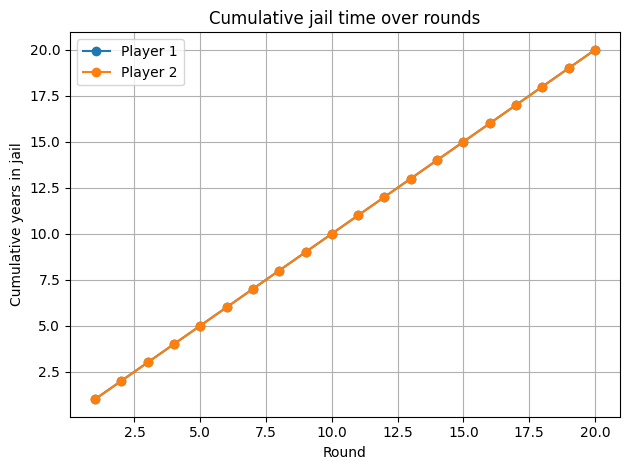

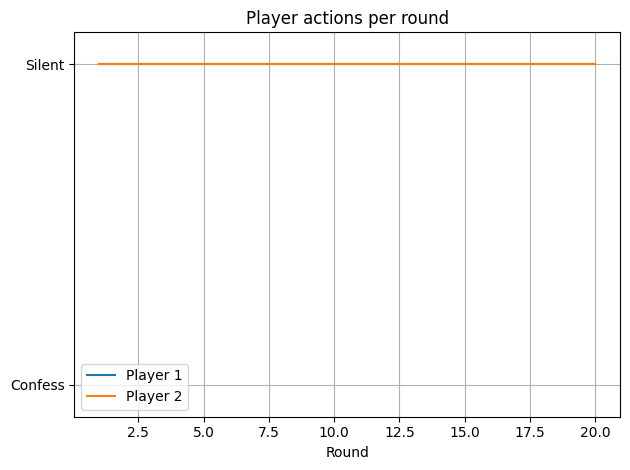

In [17]:
import numpy as np
import matplotlib.pyplot as plt
data = context_variables.data
rounds = list(range(1, int(data['i_rounds']) + 1))

# ----- Figure 1: Cumulative jail time over rounds -----
p1_cum = np.cumsum(data['player1_scores'])
p2_cum = np.cumsum(data['player2_scores'])

plt.figure()
plt.plot(rounds, p1_cum, marker='o', label='Player 1')
plt.plot(rounds, p2_cum, marker='o', label='Player 2')
plt.title('Cumulative jail time over rounds')
plt.xlabel('Round')
plt.ylabel('Cumulative years in jail')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ----- Figure 2: Actions taken each round -----
def action_to_num(actions):
    """Map 'Silent' -> 1 (Cooperate), 'Confess' -> 0 (Defect)."""
    return [1 if a.lower().startswith('s') else 0 for a in actions]

p1_action = action_to_num(data['player1_responses'])
p2_action = action_to_num(data['player2_responses'])

plt.figure()
plt.step(rounds, p1_action, where='mid', label='Player 1')
plt.step(rounds, p2_action, where='mid', label='Player 2')
plt.yticks([0, 1], ['Confess', 'Silent'])
plt.ylim(-0.1, 1.1)
plt.title('Player actions per round')
plt.xlabel('Round')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
player1.system_message

'\nYou are a participant in a very dangerous game.\nIn every round you must reply with Confess or Silent. This determines how many years in jail you will spend.\nThe maximum number of years in jail you may get is 5.\nBased on your past history, think and choose your action.\n\n=========\n\n\nYour past actions so far:\n\nRound 1: You chose Silent (you spent 1 years in jail)\n\nTotal cumulative years spent in jail: 1\n'

In [13]:
# player1.chat_messages